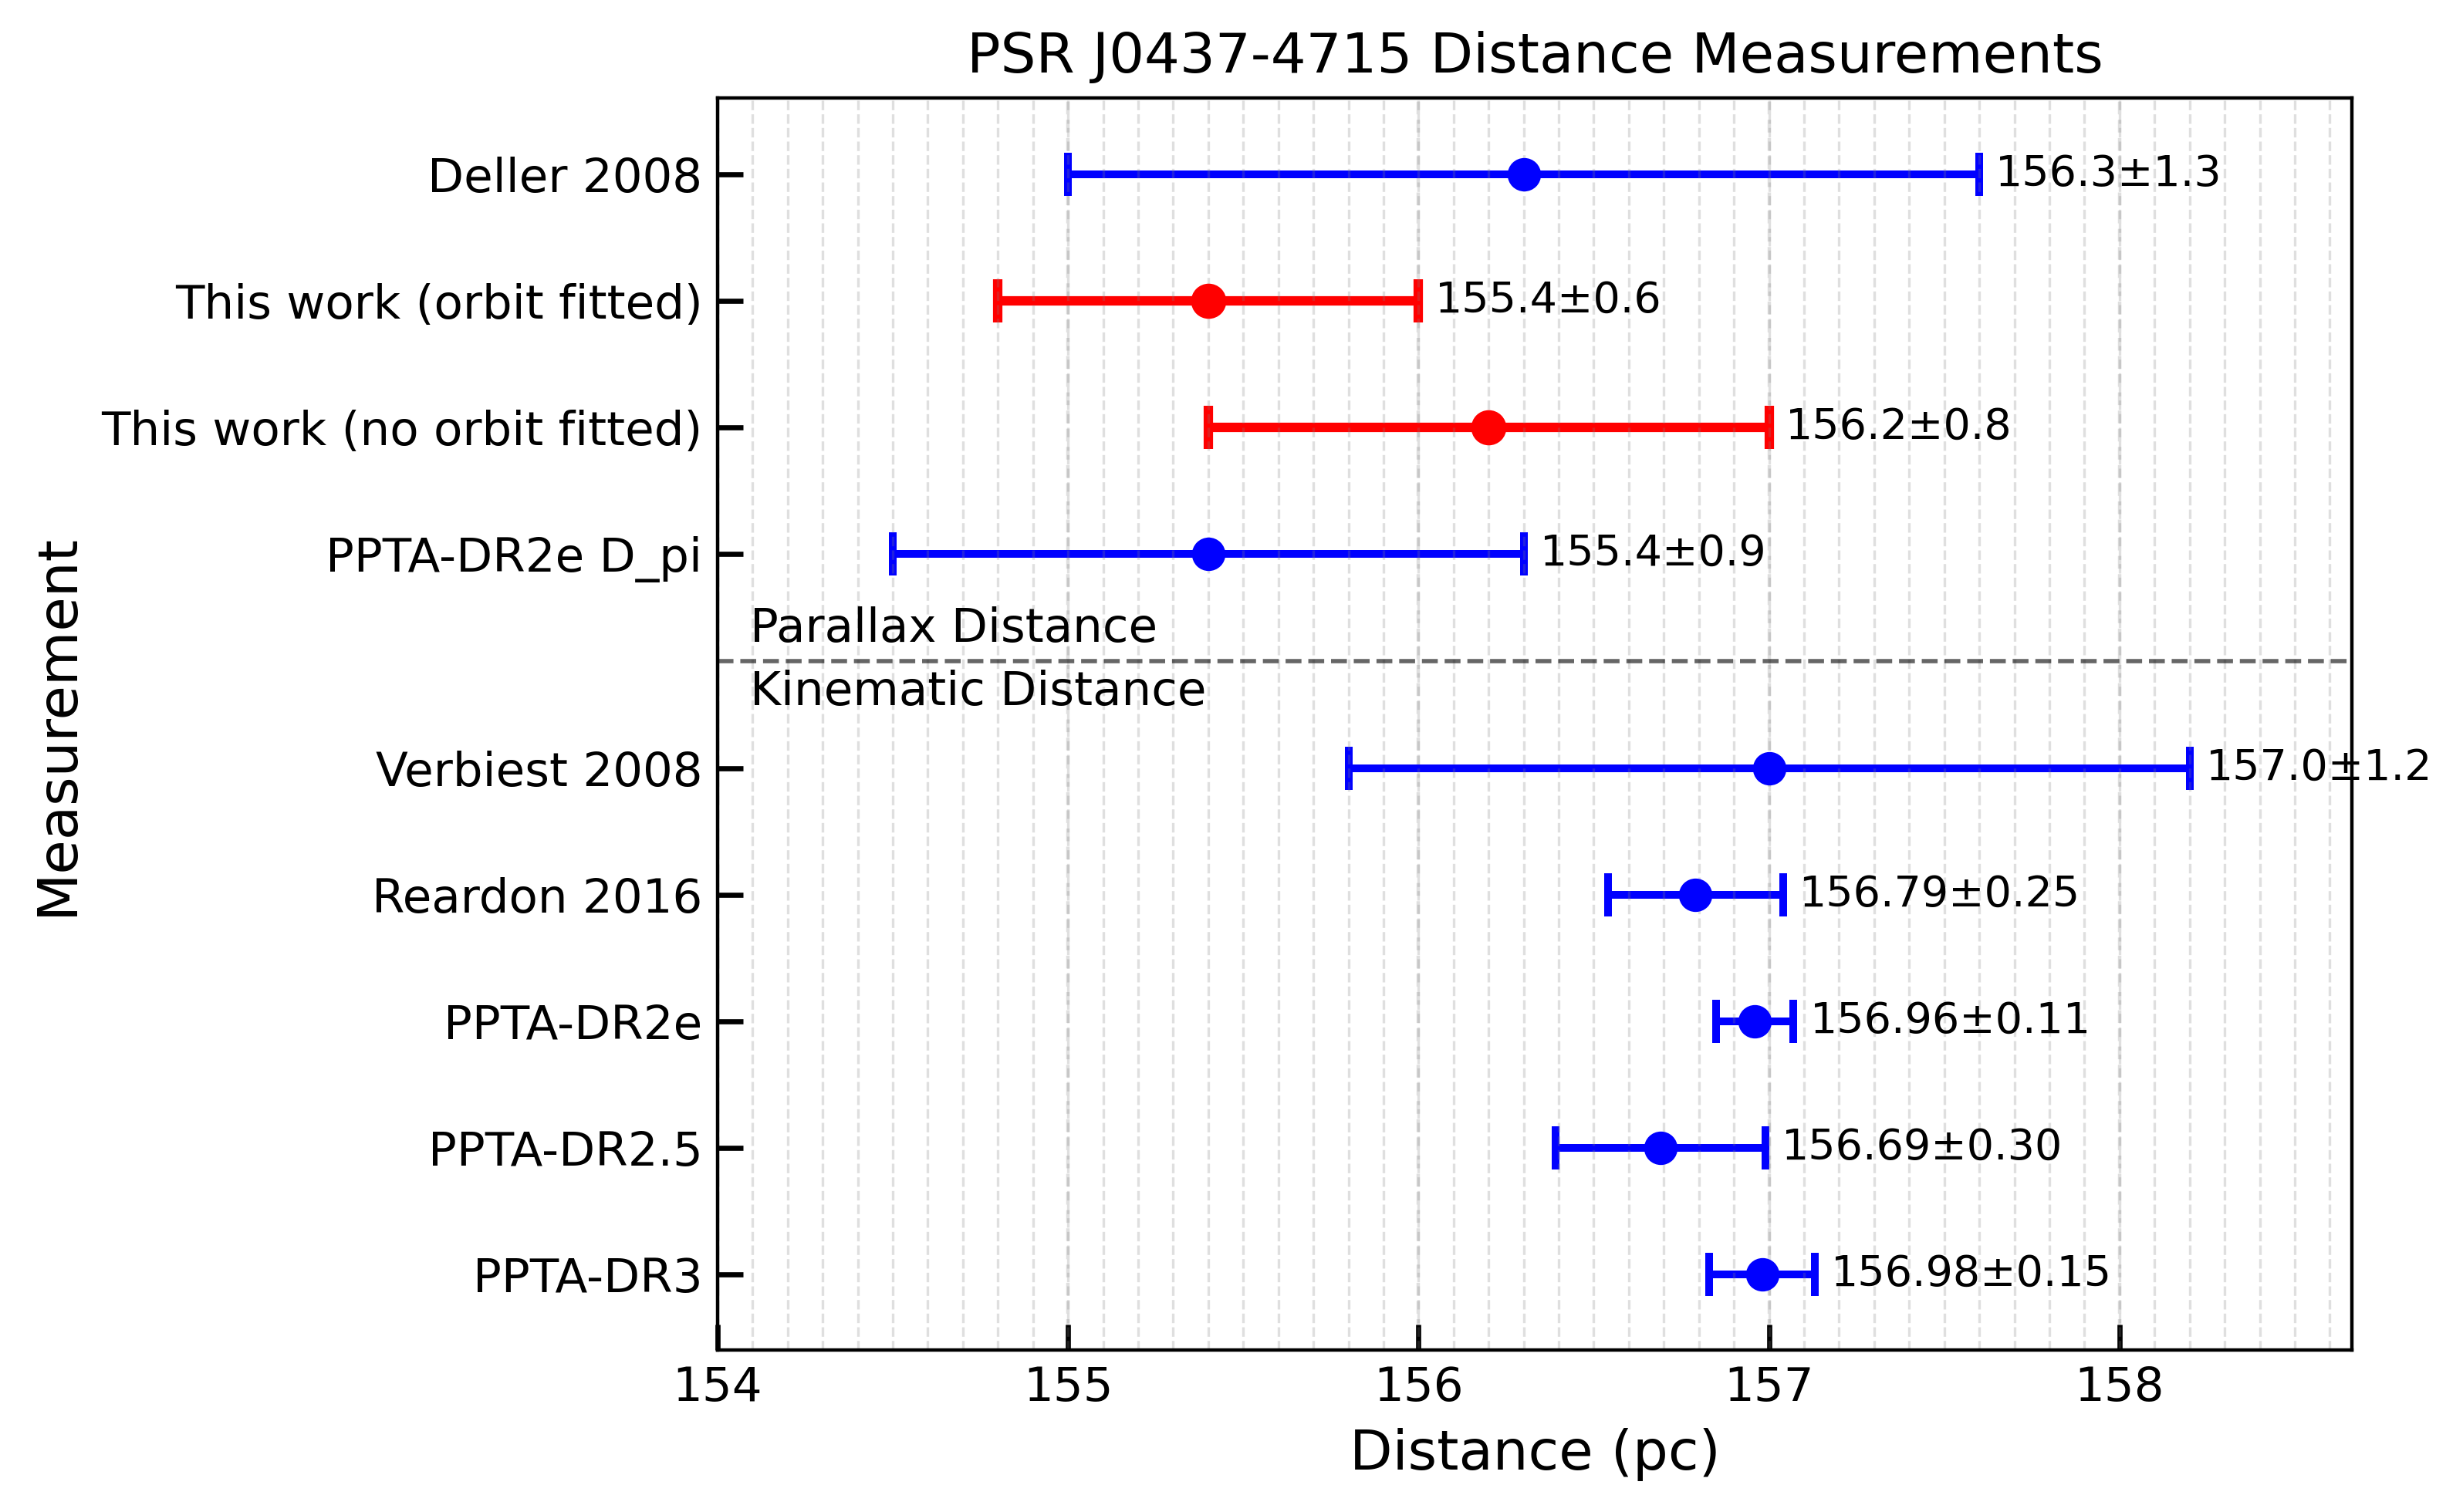

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
#                参数区（你可调整这里）
# =========================================================
fig_width = 8
fig_height = 5
fig_dpi = 400
point_size = 60
line_width = 1.8
font_size = 13
tick_size = 11
highlight_color = "red"
highlight_lw = 2.2

gap_after_index = 3   # 在 raw_data 第4行（index=3）后加空白
gap_extra = 0.7       # 额外空白的大小（0.5~1.0都挺好）
# =========================================================

raw_data = [
    "Deller 2008: 156.3±1.3",
    "This work (orbit fitted): 155.4±0.6",
    "This work (no orbit fitted): 156.2±0.8",
    "PPTA-DR2e D_pi: 155.4±0.9",
    "Verbiest 2008: 157.0±1.2",
    "Reardon 2016: 156.79±0.25",
    "PPTA-DR2e: 156.96±0.11",
    "PPTA-DR2.5: 156.69±0.30",
    "PPTA-DR3: 156.98±0.15"
]

# ------------ 解析数据（保留原始字符串精度） ----------------
labels, x_values, x_errors = [], [], []
val_strs, err_strs = [], []

for entry in raw_data:
    name, value_err = entry.split(":")
    value_str, err_str = value_err.strip().split("±")
    name = name.strip()
    value_str = value_str.strip()
    err_str = err_str.strip()

    labels.append(name)
    x_values.append(float(value_str))
    x_errors.append(float(err_str))
    val_strs.append(value_str)
    err_strs.append(err_str)

N = len(labels)

# =========================================================
#  关键：y_positions 保持从上到下顺序 + 在第4/5行之间插入额外间隔
# =========================================================
y_positions = []
for i in range(N):
    y = (N - 1 - i)
    if i > gap_after_index:  # 第5行及以下整体往下挪
        y -= gap_extra
    y_positions.append(y)

highlight_indices = [i for i, name in enumerate(labels) if "work" in name.lower()]

# =========================================================
#                      开始画图
# =========================================================
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=fig_dpi)

for i in range(N):
    y = y_positions[i]
    if i in highlight_indices:
        ax.errorbar(
            x_values[i], y,
            xerr=x_errors[i],
            fmt='o',
            color=highlight_color,
            markersize=point_size / 10,
            capsize=5,
            elinewidth=highlight_lw,
            markeredgewidth=highlight_lw
        )
    else:
        ax.errorbar(
            x_values[i], y,
            xerr=x_errors[i],
            fmt='o',
            color='blue',
            markersize=point_size / 10,
            capsize=5,
            elinewidth=line_width,
            markeredgewidth=line_width
        )

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=tick_size)

ax.set_xlabel("Distance (pc)", fontsize=font_size)
ax.set_ylabel("Measurement", fontsize=font_size)
ax.set_title("PSR J0437-4715 Distance Measurements", fontsize=font_size)

# ---------- 自动横轴范围（先算数据范围） ----------
max_err = max(x_errors)
xmin = min(x_values) - max_err - 0.1
xmax_data = max(x_values) + max_err + 0.1
span0 = xmax_data - xmin

# 给右侧文字留白（保守一点）
max_label_len = max(len(f"{v}±{e}") for v, e in zip(val_strs, err_strs))
text_pad = (0.012 * span0) * max_label_len
xmax = xmax_data + max(0.06 * span0, text_pad * 0.15)
ax.set_xlim(xmin, xmax)

# y 轴留白（根据 y_positions 的最小最大值）
ymin = min(y_positions)
ymax = max(y_positions)
ax.set_ylim(ymin - 0.6, ymax + 0.6)

# ---------- 每 0.1 加竖虚线 ----------
x_ticks_minor = np.arange(xmin, xmax, 0.1)
for xt in x_ticks_minor:
    ax.axvline(xt, linestyle='--', color='gray', alpha=0.25, linewidth=0.6)
ax.grid(axis='x', linestyle='--', alpha=0.40)

# =========================================================
#  标注：同一行 (y 不偏移)，左右自动切换避免出框
# =========================================================
span = xmax - xmin
dx = 0.01 * span
x_right_limit = xmax - 0.01 * span
x_left_limit = xmin + 0.01 * span

for i in range(N):
    x = x_values[i]
    y = y_positions[i]
    err = x_errors[i]
    label = f"{val_strs[i]}±{err_strs[i]}"

    x_right = x + err + dx
    x_left = x - err - dx

    if x_right <= x_right_limit:
        ax.text(x_right, y, label, fontsize=10, ha="left", va="center")
    elif x_left >= x_left_limit:
        ax.text(x_left, y, label, fontsize=10, ha="right", va="center")
    else:
        ax.text(min(x + dx, x_right_limit), y, label, fontsize=10, ha="left", va="center")

# =========================================================
#  分割线：第4行和第5行之间（用新的 y_positions 计算）
# =========================================================
y_sep = 0.5 * (y_positions[3] + y_positions[4])
ax.axhline(y_sep, linestyle='--', color='k', alpha=0.6, linewidth=1.0)

delta = 0.25
ax.text(0.02, y_sep + delta, "Parallax Distance",
        transform=ax.get_yaxis_transform(),
        fontsize=11, ha="left", va="center")
ax.text(0.02, y_sep - delta, "Kinematic Distance",
        transform=ax.get_yaxis_transform(),
        fontsize=11, ha="left", va="center")

# 刻度朝内
ax.tick_params(axis='both', which='both', direction='in',
               length=6, width=1.2, labelsize=tick_size)
ax.tick_params(axis='both', which='minor', direction='in', length=3)

fig.tight_layout()
fig.savefig("J0437_dist_vs.png", dpi=fig_dpi)
plt.show()


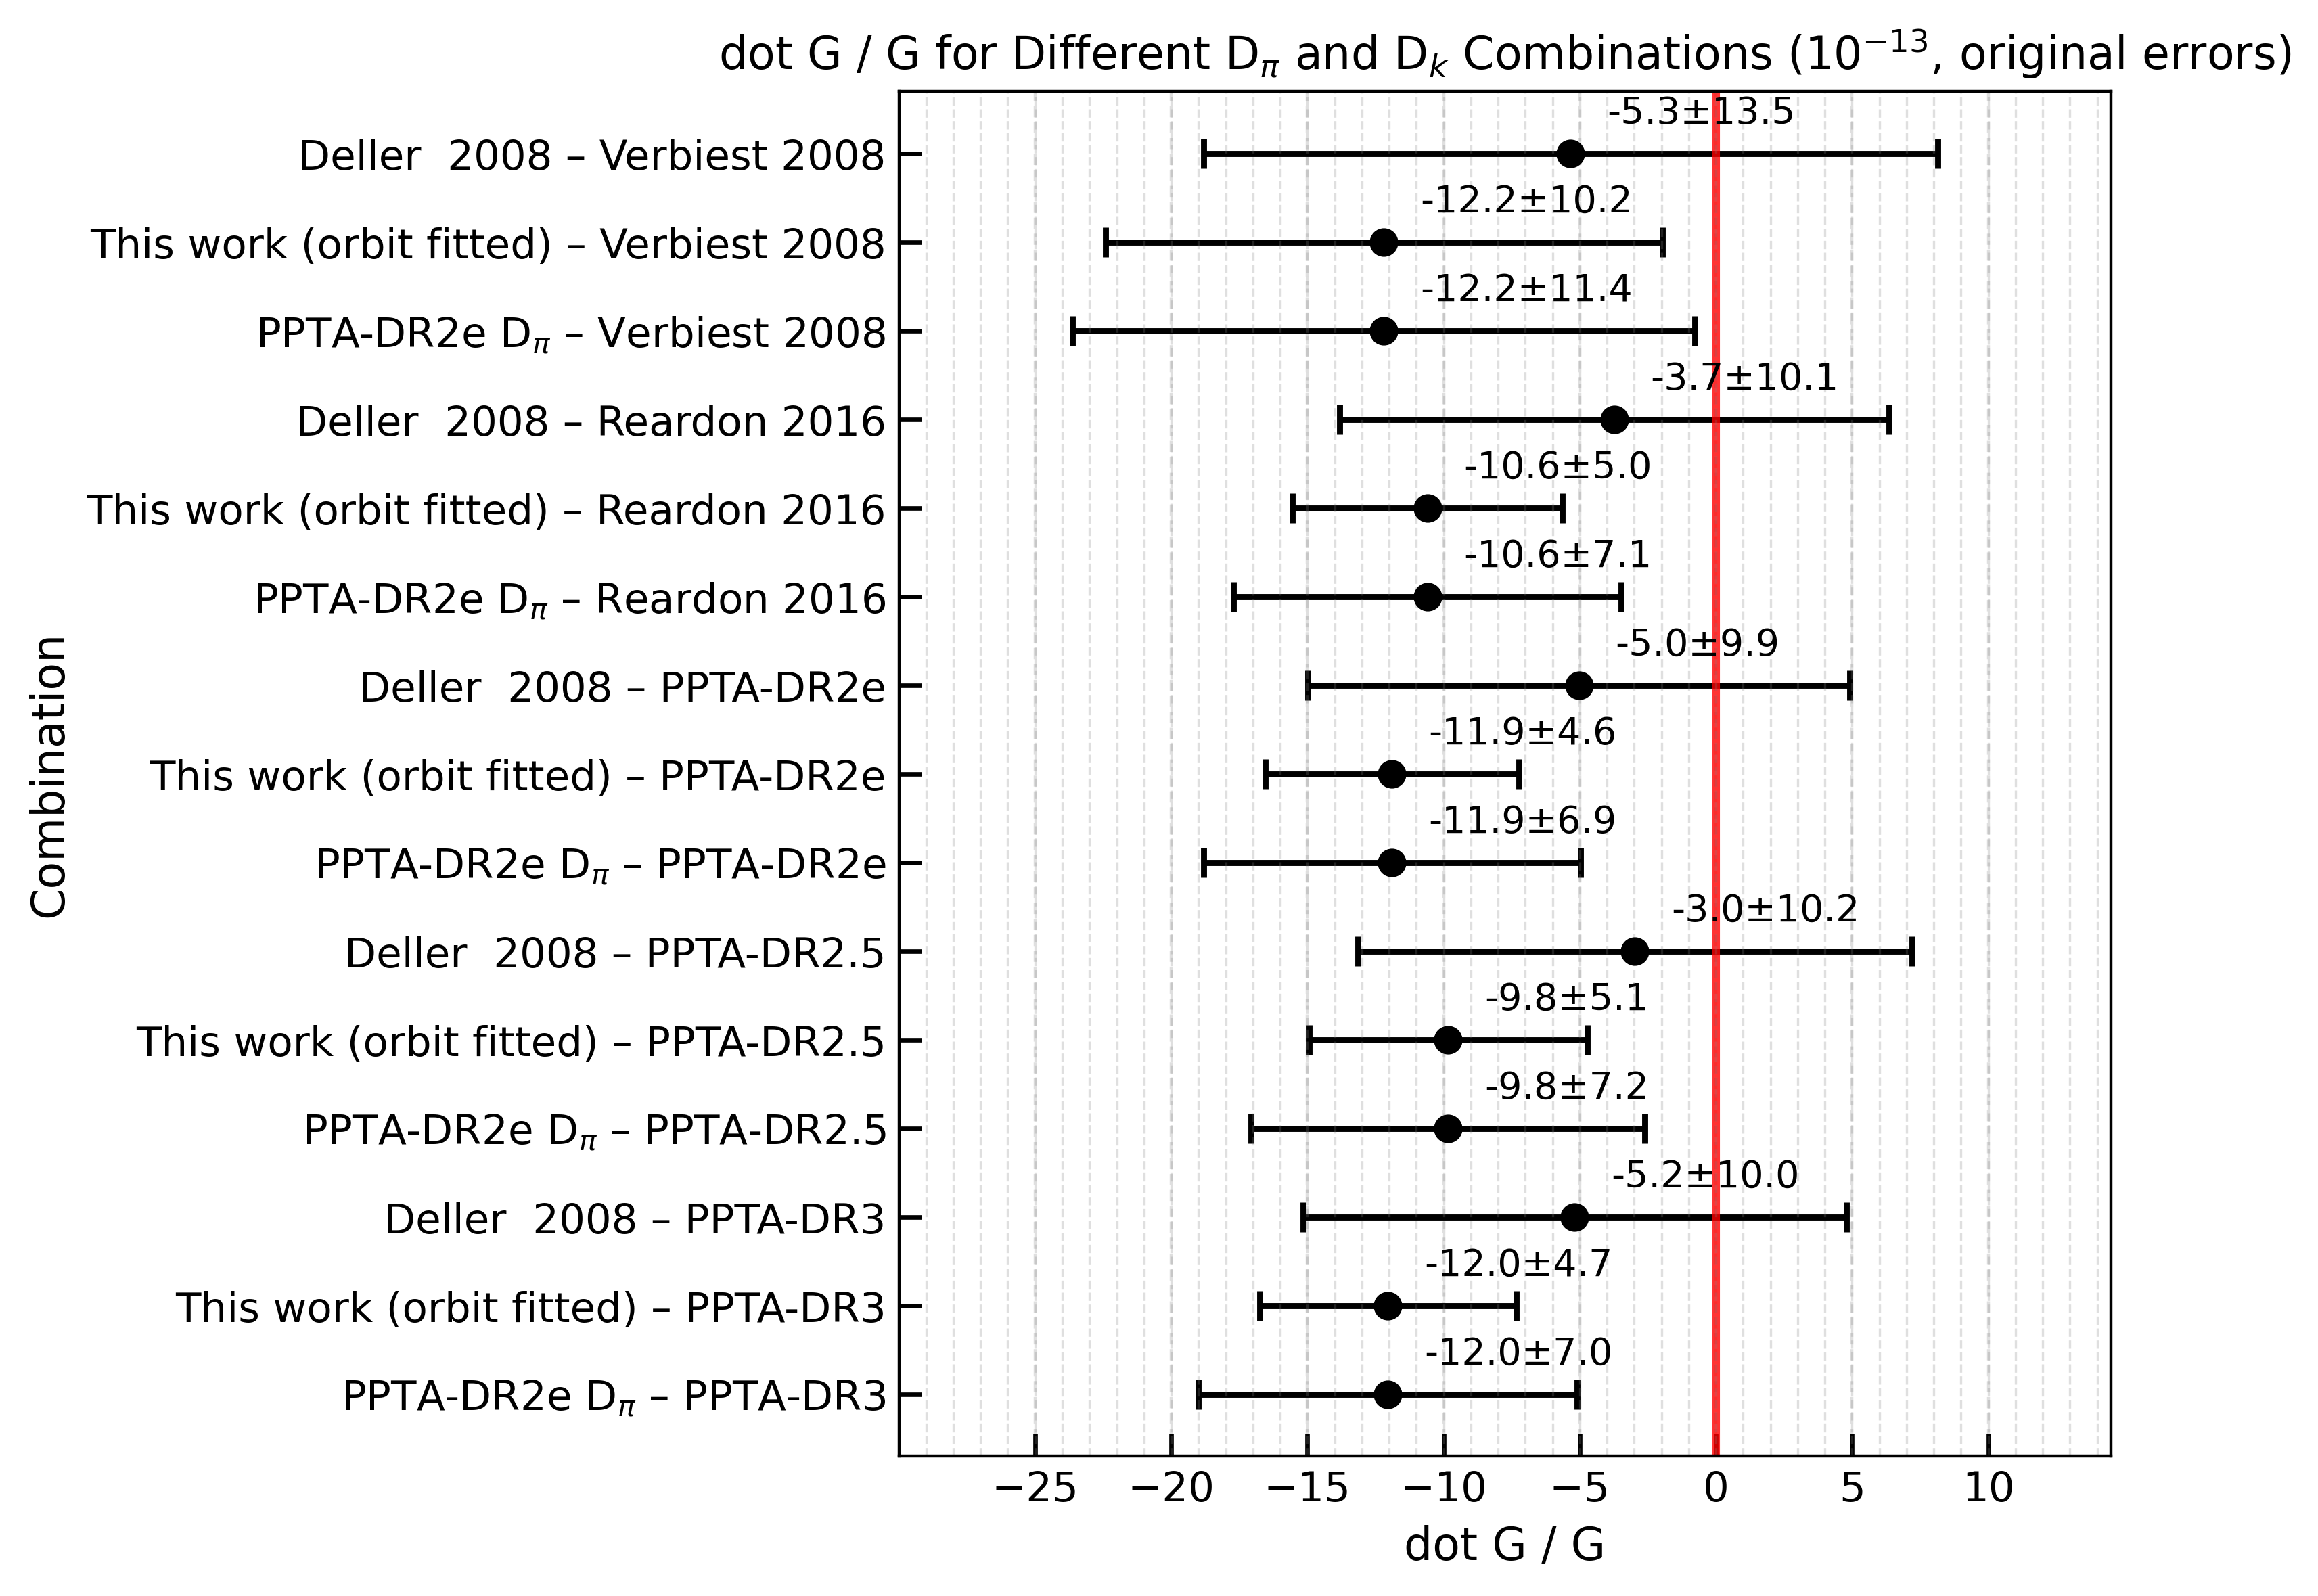

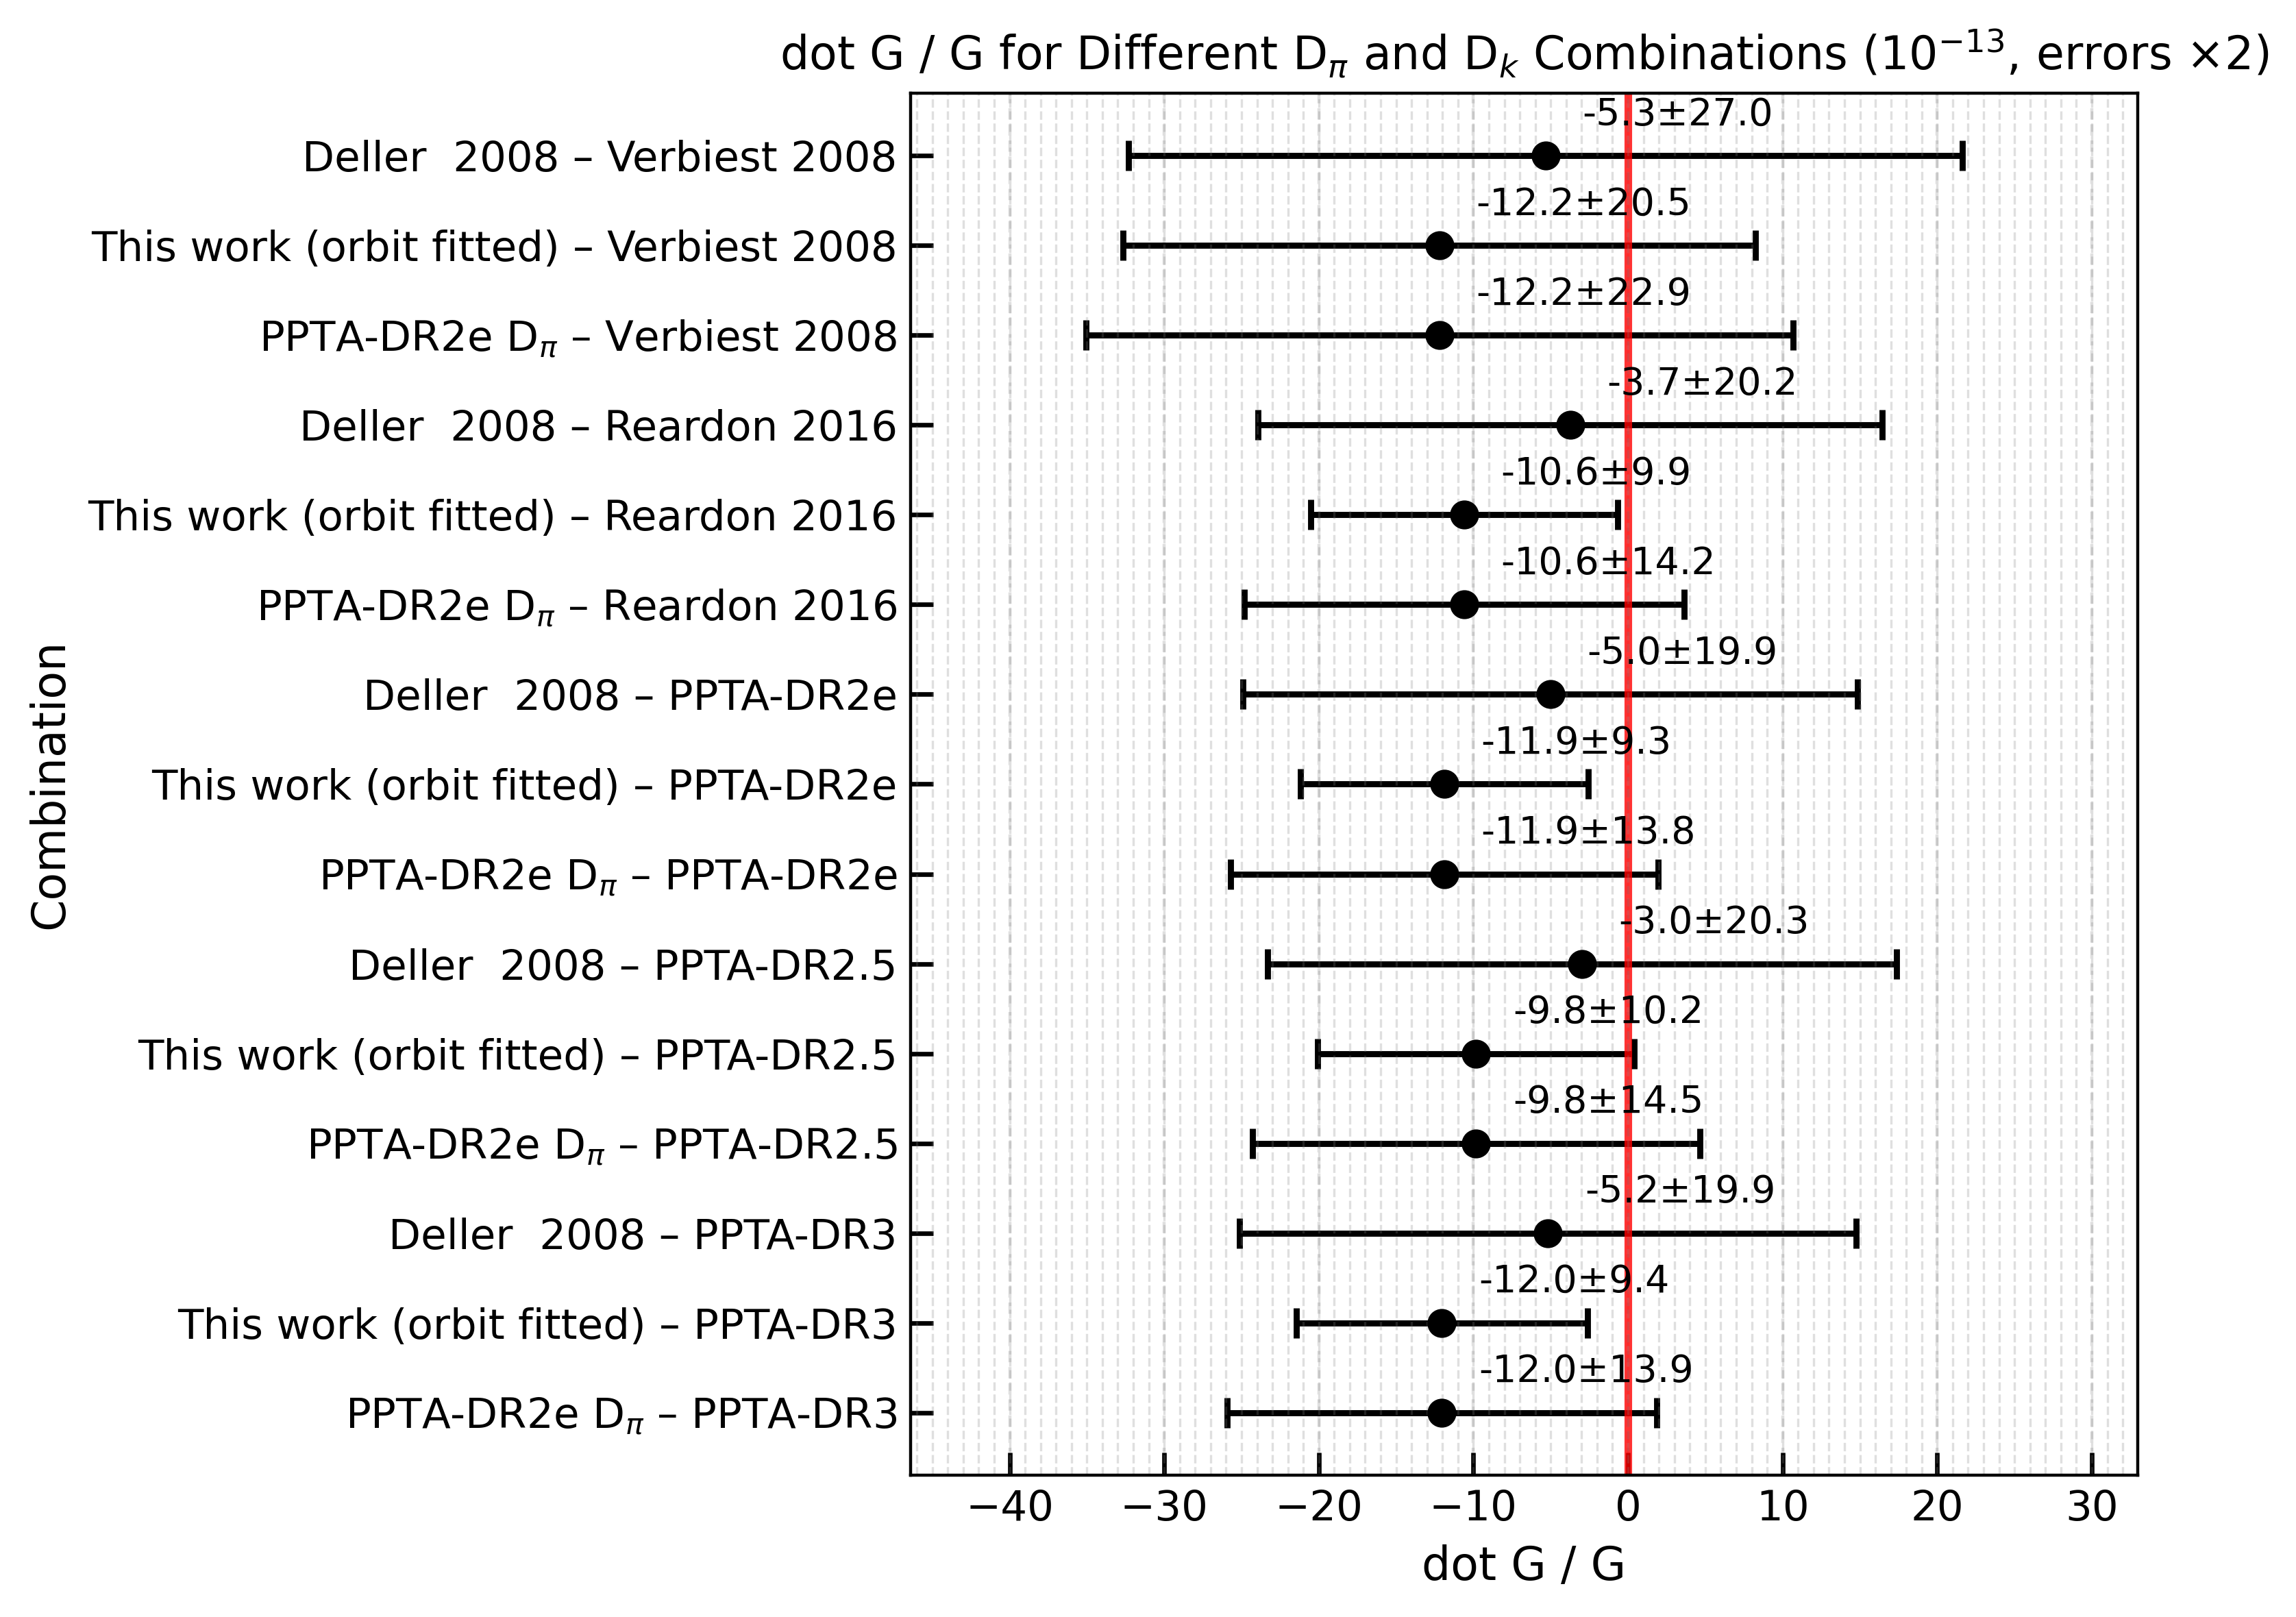

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat, umath

# =========================================================
#  距离/视差输入区（单位：pc；这里只填数值和误差）
# =========================================================
d_pi_dist_pc = {
    "Deller  2008":               (156.3, 1.3),
    "This work (orbit fitted)":  (155.4, 0.6),
#    "This work (no orbit fitted)":  (156.2, 0.8),
    "PPTA-DR2e D$_\\pi$":              (155.4, 0.9),
}

d_k_dist_pc = {
#    "Timing Old":   (157.0, 1.2),
    "Verbiest 2008":   (157.0, 1.2),
    "Reardon 2016":  (156.79, 0.25),
    "PPTA-DR2e":    (156.96, 0.11),
    "PPTA-DR2.5":   (156.69, 0.30),
    "PPTA-DR3":     (156.98, 0.15),
}

PC_TO_M = 3.09e16

# =========================================================
#  proper motion 和 c
# =========================================================
pm_x = ufloat(121.4429, 0.050)/1000/3600/180*np.pi  # rad/yr
pm_y = ufloat(-71.4715, 0.050)/1000/3600/180*np.pi  # rad/yr
mu = umath.sqrt(pm_x**2 + pm_y**2)                  # rad/yr

c = 3e8/(1/3600/24/365)  # m/yr

# =========================================================
#  计算所有 d_pi × d_k 组合的 dot G / G
# =========================================================
combo_labels = []
dG_values = []   # 中心值 (1/yr)
dG_errors = []   # 1σ (1/yr)

for k_name, (d_k_pc, d_k_err_pc) in d_k_dist_pc.items():
    d_k = ufloat(d_k_pc, d_k_err_pc) * PC_TO_M  # m
    for pi_name, (d_pi_pc, d_pi_err_pc) in d_pi_dist_pc.items():
        d_pi = ufloat(d_pi_pc, d_pi_err_pc) * PC_TO_M  # m

        label = f"{pi_name} – {k_name}"
        combo_labels.append(label)

        dG_over_G = (mu**2)/(2*c) * (d_pi - d_k)  # 1/yr

        dG_values.append(dG_over_G.n)
        dG_errors.append(dG_over_G.s)

# =========================================================
#  换算单位 (10^-13)
# =========================================================
scale_factor = 1e13
dG_values_plot = [v * scale_factor for v in dG_values]
dG_errors_plot = [e * scale_factor for e in dG_errors]       # 原始误差棒
dG_errors_plot_x2 = [2 * e for e in dG_errors_plot]          # ×2 的误差棒

y_positions = list(range(len(combo_labels)))

# ---------------------------------------------------------
# 封装一个统一的画图函数（同一版式）
# ---------------------------------------------------------
def plot_dotG(output_name, errors_list, title_suffix=""):
    fig_width = 8
    fig_height = 6
    fig_dpi = 400

    plt.figure(figsize=(fig_width, fig_height), dpi=fig_dpi)

    # 误差棒
    plt.errorbar(
        dG_values_plot,
        y_positions,
        xerr=errors_list,
        fmt="o",
        color="black",
        capsize=4,
        elinewidth=1.6,
        markeredgewidth=1.6
    )

    plt.yticks(y_positions, combo_labels, fontsize=10)
    plt.gca().invert_yaxis()

    plt.xlabel("dot G / G", fontsize=12)
    plt.ylabel("Combination", fontsize=12)
    plt.title(f"dot G / G for Different D$_\\pi$ and D$_k$ Combinations {title_suffix}",
              fontsize=12)

    # 参考线 x=0
    plt.axvline(0.0, color="red", linestyle="-", linewidth=2.0, alpha=0.8)

    # 自动范围
    xmin = min(v - e for v, e in zip(dG_values_plot, errors_list))
    xmax = max(v + e for v, e in zip(dG_values_plot, errors_list))
    margin = 0.2 * (xmax - xmin if xmax > xmin else 1.0)
    xmin -= margin
    xmax += margin
    plt.xlim(xmin, xmax)

    # 虚线网格
    x_ticks_minor = np.arange(np.floor(xmin), np.ceil(xmax) + 0.5, 1.0)
    for xt in x_ticks_minor:
        plt.axvline(xt, linestyle="--", color="gray", alpha=0.25, linewidth=0.6)

    plt.grid(axis="x", linestyle="--", alpha=0.4)

    # =====================================================
    #   ⭐ 标注数值：小数点后 1 位 ⭐
    # =====================================================
    span = xmax - xmin if xmax > xmin else 1.0
    x_offset = 0.03 * span
    y_offset = 0.25

    for x, y, v, e in zip(dG_values_plot, y_positions, dG_values_plot, errors_list):

        v_fmt = f"{v:.1f}"   # 小数点后 1 位
        e_fmt = f"{e:.1f}"   # 小数点后 1 位
        label = f"{v_fmt}±{e_fmt}"

        plt.text(
            x + x_offset,
            y - y_offset,
            label,
            fontsize=10,
            ha="left",
            va="bottom"
        )

    # 刻度线朝内
    ax = plt.gca()
    ax.tick_params(axis='both', which='both',
                   direction='in', length=6, width=1.2, labelsize=11)
    ax.tick_params(axis='both', which='minor',
                   direction='in', length=3)

    plt.tight_layout()
    plt.savefig(output_name, dpi=fig_dpi)
    plt.show()


# =========================================================
#           输出图 1（原始误差棒）
# =========================================================
plot_dotG("dotG_over_G_original.png",
          dG_errors_plot,
          title_suffix="(10$^{-13}$, original errors)")

# =========================================================
#           输出图 2（误差棒 ×2）
# =========================================================
plot_dotG("dotG_over_G_errors_x2.png",
          dG_errors_plot_x2,
          title_suffix="(10$^{-13}$, at 95$%$ certainty)")


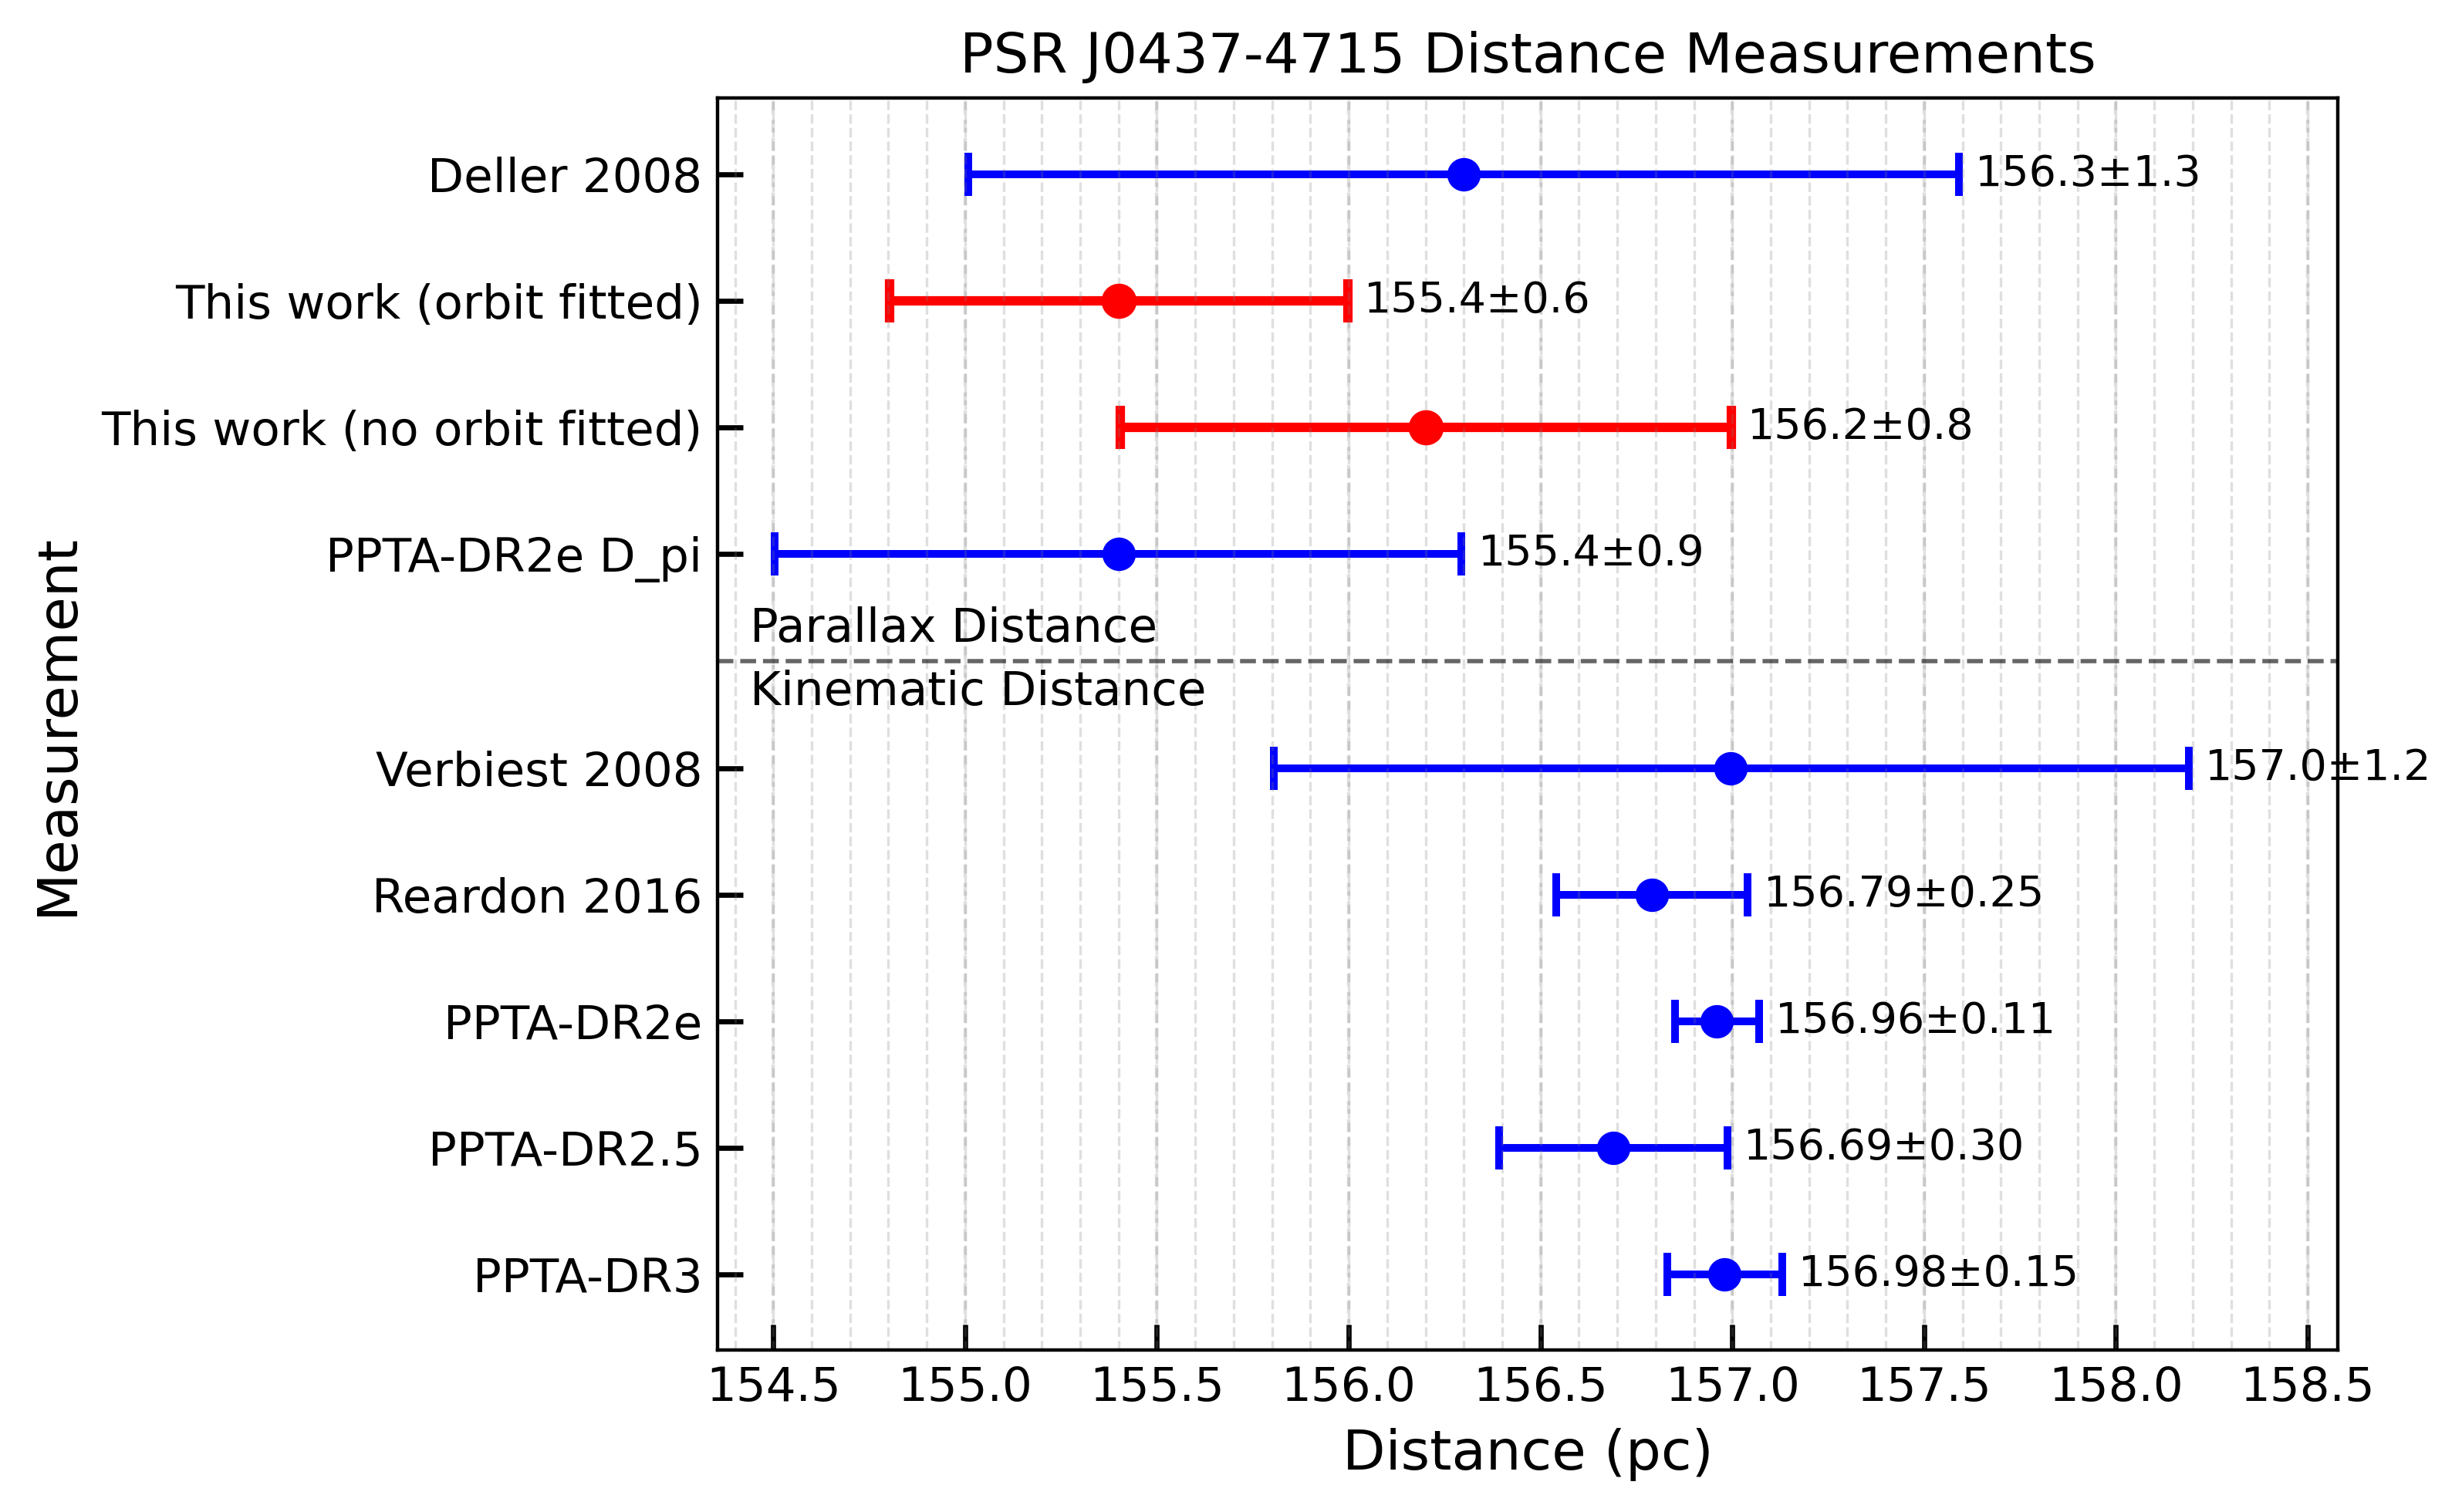

Distance plot values
use_mc_error_propagation = True
N_MC = 1000000
seed = 20260610

Label                                       input          MC median     MC -1sigma     MC +1sigma
Deller 2008                     156.300±1.300            156.29864        1.29034        1.29214
This work (orbit fitted)        155.400±0.600            155.40029        0.59772        0.59687
This work (no orbit fitted)     156.200±0.800            156.20076        0.79524        0.79598
PPTA-DR2e D_pi                  155.400±0.900            155.40003        0.89552        0.89443
Verbiest 2008                   157.000±1.200            156.99606        1.19214        1.19343
Reardon 2016                    156.790±0.250            156.78995        0.24862        0.24884
PPTA-DR2e                       156.960±0.110            156.95993        0.10950        0.10948
PPTA-DR2.5                      156.690±0.300            156.68968        0.29770        0.29819
PPTA-DR3                        156.980±

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
#                参数区（你可调整这里）
# =========================================================
fig_width = 8
fig_height = 5
fig_dpi = 400
point_size = 60
line_width = 1.8
font_size = 13
tick_size = 11

highlight_color = "red"
normal_color = "blue"
highlight_lw = 2.2

gap_after_index = 3   # 在 raw_data 第4行（index=3）后加空白
gap_extra = 0.7       # 额外空白的大小

# Monte Carlo settings
use_mc_error_propagation = True
N_MC = 1_000_000
seed = 20260610

# Output files
output_png = "J0437_dist_vs.png"
output_pdf = "J0437_dist_vs.pdf"
# =========================================================

raw_data = [
    "Deller 2008: 156.3±1.3",
    "This work (orbit fitted): 155.4±0.6",
    "This work (no orbit fitted): 156.2±0.8",
    "PPTA-DR2e D_pi: 155.4±0.9",
    "Verbiest 2008: 157.0±1.2",
    "Reardon 2016: 156.79±0.25",
    "PPTA-DR2e: 156.96±0.11",
    "PPTA-DR2.5: 156.69±0.30",
    "PPTA-DR3: 156.98±0.15"
]

# =========================================================
# 解析数据
# =========================================================
labels, input_values, input_errors = [], [], []
val_strs, err_strs = [], []

for entry in raw_data:
    name, value_err = entry.split(":")
    value_str, err_str = value_err.strip().split("±")

    name = name.strip()
    value_str = value_str.strip()
    err_str = err_str.strip()

    labels.append(name)
    input_values.append(float(value_str))
    input_errors.append(float(err_str))
    val_strs.append(value_str)
    err_strs.append(err_str)

input_values = np.array(input_values, dtype=float)
input_errors = np.array(input_errors, dtype=float)

N = len(labels)

# =========================================================
# Monte Carlo propagation for plotted distance values
#
# For direct Gaussian distance measurements, this should reproduce
# the original value and uncertainty. The advantage is that the same
# framework can later handle transformed or non-Gaussian quantities.
# =========================================================
if use_mc_error_propagation:
    rng = np.random.default_rng(seed)

    mc_medians = []
    mc_err_low = []
    mc_err_high = []

    for value, error in zip(input_values, input_errors):
        samples = rng.normal(value, error, N_MC)

        q16, q50, q84 = np.percentile(samples, [16, 50, 84])

        mc_medians.append(q50)
        mc_err_low.append(q50 - q16)
        mc_err_high.append(q84 - q50)

    x_values = np.array(mc_medians)
    xerr_low = np.array(mc_err_low)
    xerr_high = np.array(mc_err_high)

else:
    x_values = input_values.copy()
    xerr_low = input_errors.copy()
    xerr_high = input_errors.copy()

# Matplotlib allows asymmetric errors with shape (2, N)
x_errors_asym = np.vstack([xerr_low, xerr_high])

# =========================================================
# y_positions 保持从上到下顺序 + 在第4/5行之间插入额外间隔
# =========================================================
y_positions = []

for i in range(N):
    y = (N - 1 - i)

    if i > gap_after_index:
        y -= gap_extra

    y_positions.append(y)

y_positions = np.array(y_positions, dtype=float)

highlight_indices = [
    i for i, name in enumerate(labels)
    if "work" in name.lower()
]

# =========================================================
# 开始画图
# =========================================================
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=fig_dpi)

for i in range(N):
    y = y_positions[i]

    if i in highlight_indices:
        color = highlight_color
        lw = highlight_lw
    else:
        color = normal_color
        lw = line_width

    ax.errorbar(
        x_values[i], y,
        xerr=np.array([[xerr_low[i]], [xerr_high[i]]]),
        fmt="o",
        color=color,
        markersize=point_size / 10,
        capsize=5,
        elinewidth=lw,
        markeredgewidth=lw
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=tick_size)

ax.set_xlabel("Distance (pc)", fontsize=font_size)
ax.set_ylabel("Measurement", fontsize=font_size)
ax.set_title("PSR J0437-4715 Distance Measurements", fontsize=font_size)

# =========================================================
# 自动横轴范围
# =========================================================
max_err = max(np.max(xerr_low), np.max(xerr_high))

xmin = np.min(x_values - xerr_low) - 0.15
xmax_data = np.max(x_values + xerr_high) + 0.15
span0 = xmax_data - xmin

# 给右侧文字留白
max_label_len = max(len(f"{v}±{e}") for v, e in zip(val_strs, err_strs))
text_pad = (0.012 * span0) * max_label_len
xmax = xmax_data + max(0.06 * span0, text_pad * 0.15)

ax.set_xlim(xmin, xmax)

# y 轴留白
ymin = np.min(y_positions)
ymax = np.max(y_positions)
ax.set_ylim(ymin - 0.6, ymax + 0.6)

# =========================================================
# 每 0.1 pc 加竖虚线
# =========================================================
x_ticks_minor = np.arange(np.floor(xmin * 10) / 10, xmax, 0.1)

for xt in x_ticks_minor:
    ax.axvline(
        xt,
        linestyle="--",
        color="gray",
        alpha=0.25,
        linewidth=0.6
    )

ax.grid(axis="x", linestyle="--", alpha=0.40)

# =========================================================
# 标注：同一行，左右自动切换避免出框
# =========================================================
span = xmax - xmin
dx = 0.01 * span
x_right_limit = xmax - 0.01 * span
x_left_limit = xmin + 0.01 * span

for i in range(N):
    x = x_values[i]
    y = y_positions[i]

    # 用原始字符串显示，保证图上标签与文献值一致
    label = f"{val_strs[i]}±{err_strs[i]}"

    x_right = x + xerr_high[i] + dx
    x_left = x - xerr_low[i] - dx

    if x_right <= x_right_limit:
        ax.text(
            x_right, y, label,
            fontsize=10,
            ha="left",
            va="center"
        )
    elif x_left >= x_left_limit:
        ax.text(
            x_left, y, label,
            fontsize=10,
            ha="right",
            va="center"
        )
    else:
        ax.text(
            min(x + dx, x_right_limit), y, label,
            fontsize=10,
            ha="left",
            va="center"
        )

# =========================================================
# 分割线：第4行和第5行之间
# =========================================================
y_sep = 0.5 * (y_positions[gap_after_index] + y_positions[gap_after_index + 1])

ax.axhline(
    y_sep,
    linestyle="--",
    color="k",
    alpha=0.6,
    linewidth=1.0
)

delta = 0.25

ax.text(
    0.02, y_sep + delta,
    "Parallax Distance",
    transform=ax.get_yaxis_transform(),
    fontsize=11,
    ha="left",
    va="center"
)

ax.text(
    0.02, y_sep - delta,
    "Kinematic Distance",
    transform=ax.get_yaxis_transform(),
    fontsize=11,
    ha="left",
    va="center"
)

# =========================================================
# 刻度
# =========================================================
ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    length=6,
    width=1.2,
    labelsize=tick_size
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3
)

fig.tight_layout()

fig.savefig(output_png, dpi=fig_dpi, bbox_inches="tight")
fig.savefig(output_pdf, dpi=fig_dpi, bbox_inches="tight")

plt.show()

# =========================================================
# 打印 MC 检查结果
# =========================================================
print("============================================================")
print("Distance plot values")
print("============================================================")
print(f"use_mc_error_propagation = {use_mc_error_propagation}")
print(f"N_MC = {N_MC}")
print(f"seed = {seed}")
print()

print(f"{'Label':<30s} {'input':>18s} {'MC median':>18s} {'MC -1sigma':>14s} {'MC +1sigma':>14s}")

for i in range(N):
    print(
        f"{labels[i]:<30s} "
        f"{input_values[i]:8.3f}±{input_errors[i]:<7.3f} "
        f"{x_values[i]:18.5f} "
        f"{xerr_low[i]:14.5f} "
        f"{xerr_high[i]:14.5f}"
    )

print()
print(f"Saved: {output_png}")
print(f"Saved: {output_pdf}")

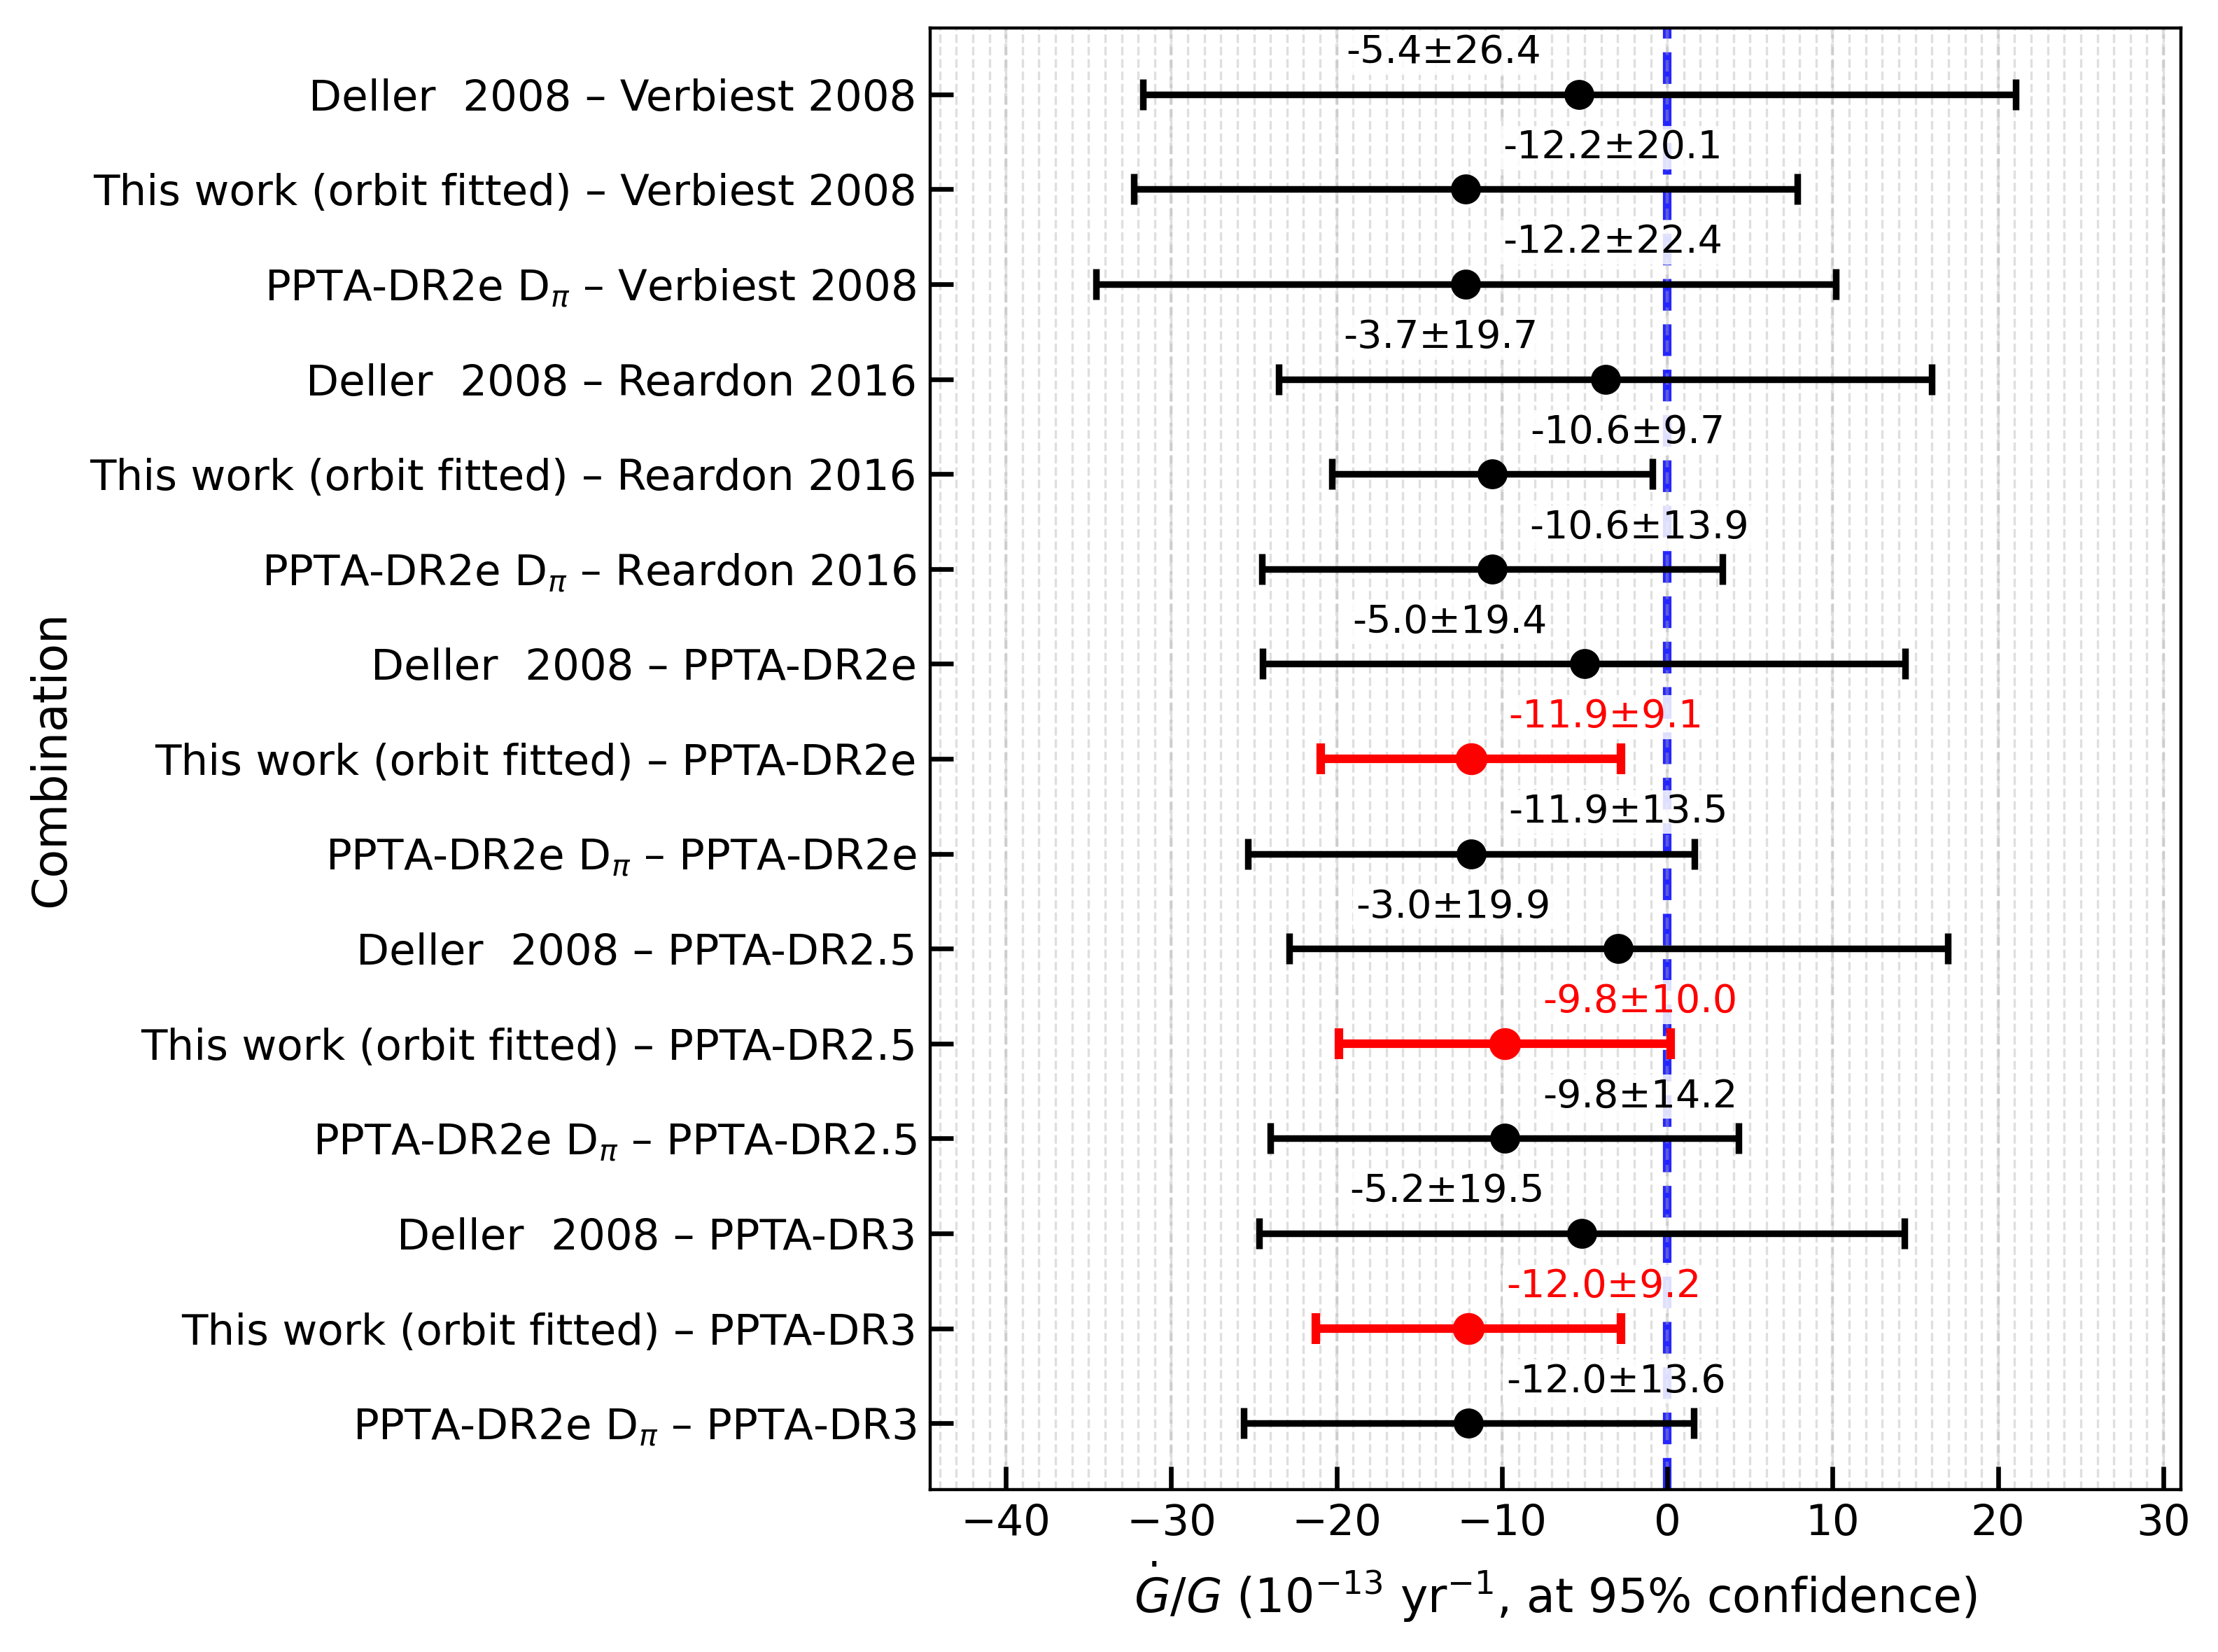

Monte Carlo dotG/G results
Unit: 10^-13 yr^-1
Error bars: 95% confidence interval from MC percentiles
N_MC = 1000000
seed = 20260610
Saved: dotG_over_G_errors_x2.png

Combination                                                 median      95% err                 95% interval
Deller  2008 – Verbiest 2008                                -5.353       26.390 [ -31.719,   21.061]
This work (orbit fitted) – Verbiest 2008                   -12.207       20.056 [ -32.262,    7.849]
PPTA-DR2e D$_\pi$ – Verbiest 2008                          -12.197       22.371 [ -34.561,   10.181]
Deller  2008 – Reardon 2016                                 -3.737       19.746 [ -23.487,   16.005]
This work (orbit fitted) – Reardon 2016                    -10.578        9.698 [ -20.274,   -0.878]
PPTA-DR2e D$_\pi$ – Reardon 2016                           -10.596       13.920 [ -24.509,    3.331]
Deller  2008 – PPTA-DR2e                                    -5.015       19.419 [ -24.472,   14.366]
This work (orbit 

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
#  距离输入区（单位：pc）
# =========================================================
d_pi_dist_pc = {
    "Deller  2008":              (156.3, 1.3),
    "This work (orbit fitted)":  (155.4, 0.6),
    # "This work (no orbit fitted)": (156.2, 0.8),
    "PPTA-DR2e D$_\\pi$":        (155.4, 0.9),
}

d_k_dist_pc = {
    # "Timing Old":    (157.0, 1.2),
    "Verbiest 2008": (157.0, 1.2),
    "Reardon 2016":  (156.79, 0.25),
    "PPTA-DR2e":     (156.96, 0.11),
    "PPTA-DR2.5":    (156.69, 0.30),
    "PPTA-DR3":      (156.98, 0.15),
}

# =========================================================
#  Monte Carlo 设置
# =========================================================
N_MC = 1_000_000
seed = 20260610
rng = np.random.default_rng(seed)

# =========================================================
#  画图参数
# =========================================================
fig_width = 8
fig_height = 6
fig_dpi = 400

marker_size = 6
eline_width = 1.7
cap_size = 4
font_size = 12
tick_size = 10
label_font_size = 10

normal_color = "black"
highlight_color = "red"
zero_line_color = "blue"

output_name = "dotG_over_G_errors_x2.png"

# =========================================================
#  物理常数
# =========================================================
PC_TO_M = 3.0856775814913673e16
c_si = 299792458.0
yr = 365.25 * 86400.0
c_m_per_yr = c_si * yr

mas_to_rad = np.pi / (180.0 * 3600.0 * 1000.0)

# =========================================================
#  proper motion 输入
#
# 这里使用 Reardon DR2e .par 里的高精度 proper motion 误差量级。
# proper motion 误差对最终结果影响很小，主要误差来自距离差。
# =========================================================
pm_ra_masyr = 121.4429
pm_ra_err_masyr = 0.0005

pm_dec_masyr = -71.4715
pm_dec_err_masyr = 0.0005

# 如果想复现旧代码较保守的 proper-motion 误差，可改成：
# pm_ra_err_masyr = 0.050
# pm_dec_err_masyr = 0.050

# =========================================================
#  抽样 proper motion
# =========================================================
pm_ra_samp = rng.normal(pm_ra_masyr, pm_ra_err_masyr, N_MC) * mas_to_rad
pm_dec_samp = rng.normal(pm_dec_masyr, pm_dec_err_masyr, N_MC) * mas_to_rad
mu_samp = np.sqrt(pm_ra_samp**2 + pm_dec_samp**2)  # rad/yr

# =========================================================
#  计算所有 D_pi × D_k 组合的 dotG/G
# =========================================================
combo_labels = []

dG_median = []
dG_err_95_low = []
dG_err_95_high = []
dG_err_95_sym = []

for k_name, (d_k_pc, d_k_err_pc) in d_k_dist_pc.items():
    d_k_samp_m = rng.normal(d_k_pc, d_k_err_pc, N_MC) * PC_TO_M

    for pi_name, (d_pi_pc, d_pi_err_pc) in d_pi_dist_pc.items():
        d_pi_samp_m = rng.normal(d_pi_pc, d_pi_err_pc, N_MC) * PC_TO_M

        label = f"{pi_name} – {k_name}"
        combo_labels.append(label)

        # dotG/G, unit: yr^-1
        dG_samp = (mu_samp**2) / (2.0 * c_m_per_yr) * (d_pi_samp_m - d_k_samp_m)

        # 换算成 10^-13 yr^-1
        dG_samp_plot = dG_samp * 1e13

        q2p5, q50, q97p5 = np.percentile(dG_samp_plot, [2.5, 50.0, 97.5])

        dG_median.append(q50)
        dG_err_95_low.append(q50 - q2p5)
        dG_err_95_high.append(q97p5 - q50)
        dG_err_95_sym.append(0.5 * (q97p5 - q2p5))

dG_median = np.array(dG_median)
dG_err_95_low = np.array(dG_err_95_low)
dG_err_95_high = np.array(dG_err_95_high)
dG_err_95_sym = np.array(dG_err_95_sym)

y_positions = np.arange(len(combo_labels))

# =========================================================
#  哪些组合标红？
#  只标红：
#  This work (orbit fitted) – PPTA-DR2e
#  This work (orbit fitted) – PPTA-DR2.5
#  This work (orbit fitted) – PPTA-DR3
# =========================================================
highlight_indices = []

for i, label in enumerate(combo_labels):
    if (
        "This work (orbit fitted)" in label
        and (
            "PPTA-DR2e" in label
            or "PPTA-DR2.5" in label
            or "PPTA-DR3" in label
        )
    ):
        highlight_indices.append(i)

# =========================================================
#  开始画图
# =========================================================
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=fig_dpi)

xerr_asym = np.vstack([dG_err_95_low, dG_err_95_high])

for i in range(len(combo_labels)):
    color = highlight_color if i in highlight_indices else normal_color
    lw = 2.2 if i in highlight_indices else eline_width

    ax.errorbar(
        dG_median[i],
        y_positions[i],
        xerr=np.array([[dG_err_95_low[i]], [dG_err_95_high[i]]]),
        fmt="o",
        color=color,
        markersize=marker_size,
        capsize=cap_size,
        elinewidth=lw,
        markeredgewidth=lw,
        zorder=3
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(combo_labels, fontsize=tick_size)
ax.invert_yaxis()

ax.set_xlabel(r"$\dot G/G$ ($10^{-13}\ {\rm yr^{-1}}$, at 95% confidence)", fontsize=font_size)
ax.set_ylabel("Combination", fontsize=font_size)

# =========================================================
#  自动范围
# =========================================================
xmin = np.min(dG_median - dG_err_95_low)
xmax = np.max(dG_median + dG_err_95_high)
margin = 0.18 * (xmax - xmin if xmax > xmin else 1.0)
xmin -= margin
xmax += margin
ax.set_xlim(xmin, xmax)

# =========================================================
#  x=0 基线：蓝色虚线
#  zorder 设低一点，避免压住点和文字
# =========================================================
ax.axvline(
    0.0,
    color=zero_line_color,
    linestyle="--",
    linewidth=2.2,
    alpha=0.85,
    zorder=1
)

# =========================================================
#  虚线网格
# =========================================================
x_ticks_minor = np.arange(np.floor(xmin), np.ceil(xmax) + 0.5, 1.0)

for xt in x_ticks_minor:
    ax.axvline(
        xt,
        linestyle="--",
        color="gray",
        alpha=0.25,
        linewidth=0.6,
        zorder=0
    )

ax.grid(axis="x", linestyle="--", alpha=0.4)

# =========================================================
#  标注数值：避免被 x=0 蓝色虚线挡住
#
#  策略：
#  1. 默认把文字放在点右侧；
#  2. 如果文字位置太靠近 x=0，就放到点左侧；
#  3. 文字加白色半透明背景框，进一步避免被线挡住。
# =========================================================
span = xmax - xmin if xmax > xmin else 1.0
x_offset = 0.03 * span
y_offset = 0.24

zero_avoid_width = 0.08 * span

for i, (x, y, e_sym) in enumerate(zip(dG_median, y_positions, dG_err_95_sym)):
    label = f"{x:.1f}±{e_sym:.1f}"

    # 默认右侧标注
    x_text = x + x_offset
    ha = "left"

    # 如果右侧标注太靠近 0 线，则改到左侧
    if abs(x_text) < zero_avoid_width:
        x_text = x - x_offset
        ha = "right"

    # 如果放左侧还是太靠近 0，则再往左挪一点
    if abs(x_text) < zero_avoid_width:
        x_text = x - 1.8 * x_offset
        ha = "right"

    color = highlight_color if i in highlight_indices else normal_color

    ax.text(
        x_text,
        y - y_offset,
        label,
        fontsize=label_font_size,
        color=color,
        ha=ha,
        va="bottom",
        zorder=5,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.85,
            pad=0.8
        )
    )

# =========================================================
#  刻度线朝内
# =========================================================
ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    length=6,
    width=1.2,
    labelsize=11
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3
)

fig.tight_layout()
fig.savefig(output_name, dpi=fig_dpi, bbox_inches="tight")
plt.show()

# =========================================================
#  打印结果表
# =========================================================
print("============================================================")
print("Monte Carlo dotG/G results")
print("Unit: 10^-13 yr^-1")
print("Error bars: 95% confidence interval from MC percentiles")
print("============================================================")
print(f"N_MC = {N_MC}")
print(f"seed = {seed}")
print(f"Saved: {output_name}")
print()

print(
    f"{'Combination':<55s} "
    f"{'median':>10s} "
    f"{'95% err':>12s} "
    f"{'95% interval':>28s}"
)

for label, med, e95, lo95, hi95 in zip(
    combo_labels,
    dG_median,
    dG_err_95_sym,
    dG_median - dG_err_95_low,
    dG_median + dG_err_95_high
):
    print(
        f"{label:<55s} "
        f"{med:10.3f} "
        f"{e95:12.3f} "
        f"[{lo95:8.3f}, {hi95:8.3f}]"
    )